# General Parameters

In [1]:
### Load Python Lib##### 
### plot_FFcompsr_Q2max.py
### Plot form factor ratios vs. Q^2max for fits w/, w/o sum rules with stat errors.
########
import numpy as np
from math import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
import os, sys, traceback

#very import to enable this so the plots can be showed in the page
get_ipython().magic(u'matplotlib inline')

# Use LaTeX font.
plt.rc('text', usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':20})

import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties( size=12)

In [2]:
## Input Parameters
Q2max = 1000
Q2str = str(Q2max)
Q2plot =10000
kmax = 12
#kmax=int(sys.argv[1])

fitdata = 'world'
#Q2max = int(raw_input('Max Q2 Fit =  '))
#Q2plot = float(raw_input('Max Q2 Plot = '))
#kmax = int(raw_input('Max Z = '))

bnd = '5'
mod = 't0fix7'
#mod='t0zero'
#mode=sys.argv[2]
GM0 = 2.79284356
GE0 = 1

# Load Data

In [3]:
## Dipole FF
Lambda2 = 0.71
GE0 = 1
GM0 = 2.792847356
def GD(Q2):
    return 1./(1+Q2/Lambda2)**2


## Load World+Pol+Mainz Sum-Rules baseline Fitting Results

In [4]:
fit_date='may23'

In [5]:
##Load Q2max=1000 Fitting results#{{{
folder = '../%s_all_FF/z'%fit_date+str(kmax) # folder containing central fits
filename=folder+'/Round6_all_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'.dat'
if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2 = np.zeros(N, dtype=float)
Z = np.zeros(N, dtype=float)
GE_fit = np.zeros(N, dtype=float)
GE_pos = np.zeros(N, dtype=float)
GE_neg = np.zeros(N, dtype=float)
GM_fit = np.zeros(N, dtype=float)
GM_pos = np.zeros(N, dtype=float)
GM_neg = np.zeros(N, dtype=float)
GE_fit_rat = np.zeros(N, dtype=float)
GE_pos_rat = np.zeros(N, dtype=float)
GE_neg_rat = np.zeros(N, dtype=float)
GM_fit_rat = np.zeros(N, dtype=float)
GM_pos_rat = np.zeros(N, dtype=float)
GM_neg_rat = np.zeros(N, dtype=float)
GEGM_fit_rat = np.zeros(N, dtype=float)
GEGM_pos_rat = np.zeros(N, dtype=float)
GEGM_neg_rat = np.zeros(N, dtype=float)
GE_err = np.zeros(N, dtype=float)
GM_err = np.zeros(N, dtype=float)
GEGM_err = np.zeros(N, dtype=float)

GEd = np.zeros(N, dtype=float)
GMd = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2[i]=float(values[0])
    Z[i]=float(values[1])

    GE_fit[i]=float(values[2])
    GE_pos[i]=float(values[2])+abs(float(values[3]))
    GE_neg[i]=float(values[2])-abs(float(values[3]))
    GM_fit[i]=float(values[4])
    GM_pos[i]=float(values[4])+abs(float(values[5]))
    GM_neg[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat[i]=float(values[6])
    GE_pos_rat[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat[i]=float(values[8])
    GM_pos_rat[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat[i]=float(values[10])+abs(GEGM_err1)
    GEGM_neg_rat[i]=float(values[10])-abs(GEGM_err1)
 
    GEd[i] = GD(Q2[i]) * GE0
    GMd[i] = GD(Q2[i]) * GM0
    GE_err[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err[i] = GEGM_err1/float(values[10])

values = fitlines[2016].split()
erad = float(values[0])
derad = float(values[1])
mrad = float(values[2])
dmrad = float(values[3])

values = fitlines[2015].split()
ndof = float(values[0])
num_tot = float(values[1])
num_Mainz = float(values[2])
num_world = float(values[3])
num_pol = float(values[4])

values = fitlines[2014].split()
redchi2 = float(values[0])
chi2 = float(values[1])
chi2xsMainz = float(values[2])
chi2xsworld = float(values[3])
chi2pol = float(values[4])
chi2gecoef = float(values[5])
chi2gmcoef = float(values[6])
chi2csyst = float(values[7])
chi2NMainz = float(values[8])
chi2Nworld = float(values[9])
chi2gefake= float(values[10])
chi2gmfake= float(values[11])
chi2gefakeHQ= float(values[12])
chi2gmfakeHQ= float(values[13])

#}}}

file exist ../may23_all_FF/z12/Round6_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat


## Fit Load World+Pol Sum-Rules baseline Fitting Results

In [6]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'world'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'
if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_WP = np.zeros(N, dtype=float)
GE_fit_WP = np.zeros(N, dtype=float)
GE_pos_WP = np.zeros(N, dtype=float)
GE_neg_WP = np.zeros(N, dtype=float)
GM_fit_WP = np.zeros(N, dtype=float)
GM_pos_WP = np.zeros(N, dtype=float)
GM_neg_WP = np.zeros(N, dtype=float)
GE_fit_rat_WP = np.zeros(N, dtype=float)
GE_pos_rat_WP = np.zeros(N, dtype=float)
GE_neg_rat_WP = np.zeros(N, dtype=float)
GM_fit_rat_WP = np.zeros(N, dtype=float)
GM_pos_rat_WP = np.zeros(N, dtype=float)
GM_neg_rat_WP = np.zeros(N, dtype=float)
GEGM_fit_rat_WP = np.zeros(N, dtype=float)
GEGM_pos_rat_WP = np.zeros(N, dtype=float)
GEGM_neg_rat_WP = np.zeros(N, dtype=float)
GE_err_WP = np.zeros(N, dtype=float)
GM_err_WP = np.zeros(N, dtype=float)
GEGM_err_WP = np.zeros(N, dtype=float)

GEd_WP = np.zeros(N, dtype=float)
GMd_WP = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_WP[i]=float(values[0])
    GE_fit_WP[i]=float(values[2])
    GE_pos_WP[i]=float(values[2])+abs(float(values[3]))
    GE_neg_WP[i]=float(values[2])-abs(float(values[3]))
    GM_fit_WP[i]=float(values[4])
    GM_pos_WP[i]=float(values[4])+abs(float(values[5]))
    GM_neg_WP[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_WP[i]=float(values[6])
    GE_pos_rat_WP[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_WP[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_WP[i]=float(values[8])
    GM_pos_rat_WP[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_WP[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_WP[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_WP[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_WP[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_WP[i] = GD(Q2_WP[i]) * GE0
    GMd_WP[i] = GD(Q2_WP[i]) * GM0
    GE_err_WP[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_WP[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_WP[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_WP = float(values[0])
derad_WP = float(values[1])
mrad_WP = float(values[2])
dmrad_WP = float(values[3])

values = fitlines[2015].split()
ndof_WP = float(values[0])
num_tot_WP = float(values[1])
num_Mainz_WP = float(values[2])
num_world_WP = float(values[3])
num_pol_WP = float(values[4])

values = fitlines[2014].split()
redchi2_WP = float(values[0])
chi2_WP = float(values[1])
chi2xsMainz_WP = float(values[2])
chi2xsworld_WP = float(values[3])
chi2pol_WP = float(values[4])
chi2gecoef_WP = float(values[5])
chi2gmcoef_WP = float(values[6])
chi2csyst_WP = float(values[7])
chi2NMainz_WP = float(values[8])
chi2Nworld_WP = float(values[9])
chi2gefake_WP = float(values[10])
chi2gmfake_WP = float(values[11])
chi2gefakeHQ_WP = float(values[12])
chi2gmfakeHQ_WP = float(values[13])

#}}}

file exist ../may23_world_FF/z12/Round6_world_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat


## Fit Load Main-Only Sum-Rules baseline Fitting Results

In [7]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'Mainz'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'
if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_MZ = np.zeros(N, dtype=float)
GE_fit_MZ = np.zeros(N, dtype=float)
GE_pos_MZ = np.zeros(N, dtype=float)
GE_neg_MZ = np.zeros(N, dtype=float)
GM_fit_MZ = np.zeros(N, dtype=float)
GM_pos_MZ = np.zeros(N, dtype=float)
GM_neg_MZ = np.zeros(N, dtype=float)
GE_fit_rat_MZ = np.zeros(N, dtype=float)
GE_pos_rat_MZ = np.zeros(N, dtype=float)
GE_neg_rat_MZ = np.zeros(N, dtype=float)
GM_fit_rat_MZ = np.zeros(N, dtype=float)
GM_pos_rat_MZ = np.zeros(N, dtype=float)
GM_neg_rat_MZ = np.zeros(N, dtype=float)
GEGM_fit_rat_MZ = np.zeros(N, dtype=float)
GEGM_pos_rat_MZ = np.zeros(N, dtype=float)
GEGM_neg_rat_MZ = np.zeros(N, dtype=float)
GE_err_MZ = np.zeros(N, dtype=float)
GM_err_MZ = np.zeros(N, dtype=float)
GEGM_err_MZ = np.zeros(N, dtype=float)

GEd_MZ = np.zeros(N, dtype=float)
GMd_MZ = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_MZ[i]=float(values[0])
    GE_fit_MZ[i]=float(values[2])
    GE_pos_MZ[i]=float(values[2])+abs(float(values[3]))
    GE_neg_MZ[i]=float(values[2])-abs(float(values[3]))
    GM_fit_MZ[i]=float(values[4])
    GM_pos_MZ[i]=float(values[4])+abs(float(values[5]))
    GM_neg_MZ[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_MZ[i]=float(values[6])
    GE_pos_rat_MZ[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_MZ[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_MZ[i]=float(values[8])
    GM_pos_rat_MZ[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_MZ[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_MZ[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_MZ[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_MZ[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_MZ[i] = GD(Q2_MZ[i]) * GE0
    GMd_MZ[i] = GD(Q2_MZ[i]) * GM0
    GE_err_MZ[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_MZ[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_MZ[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_MZ = float(values[0])
derad_MZ = float(values[1])
mrad_MZ = float(values[2])
dmrad_MZ = float(values[3])

values = fitlines[2015].split()
ndof_MZ = float(values[0])
num_tot_MZ = float(values[1])
num_Mainz_MZ = float(values[2])
num_world_MZ = float(values[3])
num_pol_MZ = float(values[4])

values = fitlines[2014].split()
redchi2_MZ = float(values[0])
chi2_MZ = float(values[1])
chi2xsMainz_MZ = float(values[2])
chi2xsworld_MZ = float(values[3])
chi2pol_MZ = float(values[4])
chi2gecoef_MZ = float(values[5])
chi2gmcoef_MZ = float(values[6])
chi2csyst_MZ = float(values[7])
chi2NMainz_MZ = float(values[8])
chi2Nworld_MZ = float(values[9])
chi2gefake_MZ = float(values[10])
chi2gmfake_MZ = float(values[11])
chi2gefakeHQ_MZ = float(values[12])
chi2gmfakeHQ_MZ = float(values[13])

#}}}

file exist ../may23_Mainz_FF/z12/Round6_Mainz_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat


## Fit w/o radius contraints

In [8]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../may23_%s_FF/z'%comp+str(kmax1) # folder containing central fits
filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noRad.dat'
if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noRad = np.zeros(N, dtype=float)
GE_fit_noRad = np.zeros(N, dtype=float)
GE_pos_noRad = np.zeros(N, dtype=float)
GE_neg_noRad = np.zeros(N, dtype=float)
GM_fit_noRad = np.zeros(N, dtype=float)
GM_pos_noRad = np.zeros(N, dtype=float)
GM_neg_noRad = np.zeros(N, dtype=float)
GE_fit_rat_noRad = np.zeros(N, dtype=float)
GE_pos_rat_noRad = np.zeros(N, dtype=float)
GE_neg_rat_noRad = np.zeros(N, dtype=float)
GM_fit_rat_noRad = np.zeros(N, dtype=float)
GM_pos_rat_noRad = np.zeros(N, dtype=float)
GM_neg_rat_noRad = np.zeros(N, dtype=float)
GEGM_fit_rat_noRad = np.zeros(N, dtype=float)
GEGM_pos_rat_noRad = np.zeros(N, dtype=float)
GEGM_neg_rat_noRad = np.zeros(N, dtype=float)
GE_err_noRad = np.zeros(N, dtype=float)
GM_err_noRad = np.zeros(N, dtype=float)
GEGM_err_noRad = np.zeros(N, dtype=float)

GEd_noRad = np.zeros(N, dtype=float)
GMd_noRad = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noRad[i]=float(values[0])
    GE_fit_noRad[i]=float(values[2])
    GE_pos_noRad[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noRad[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noRad[i]=float(values[4])
    GM_pos_noRad[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noRad[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noRad[i]=float(values[6])
    GE_pos_rat_noRad[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noRad[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noRad[i]=float(values[8])
    GM_pos_rat_noRad[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noRad[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noRad[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noRad[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noRad[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noRad[i] = GD(Q2_noRad[i]) * GE0
    GMd_noRad[i] = GD(Q2_noRad[i]) * GM0
    GE_err_noRad[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noRad[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noRad[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_noRad = float(values[0])
derad_noRad = float(values[1])
mrad_noRad = float(values[2])
dmrad_noRad = float(values[3])

values = fitlines[2015].split()
ndof_noRad = float(values[0])
num_tot_noRad = float(values[1])
num_Mainz_noRad = float(values[2])
num_world_noRad = float(values[3])
num_pol_noRad = float(values[4])

values = fitlines[2014].split()
redchi2_noRad = float(values[0])
chi2_noRad = float(values[1])
chi2xsMainz_noRad = float(values[2])
chi2xsworld_noRad = float(values[3])
chi2pol_noRad = float(values[4])
chi2gecoef_noRad = float(values[5])
chi2gmcoef_noRad = float(values[6])
chi2csyst_noRad = float(values[7])
chi2NMainz_noRad = float(values[8])
chi2Nworld_noRad = float(values[9])
chi2gefake_noRad = float(values[10])
chi2gmfake_noRad = float(values[11])
chi2gefakeHQ_noRad = float(values[12])
chi2gmfakeHQ_noRad = float(values[13])

#}}}

file exist ../may23_all_FF/z12/Round6_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noRad.dat


## Fit w/o Extra TPE contrains

In [9]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../may23_%s_FF/z'%comp+str(kmax1) # folder containing central fits
filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noExtraTPE.dat'
if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noTPE = np.zeros(N, dtype=float)
GE_fit_noTPE = np.zeros(N, dtype=float)
GE_pos_noTPE = np.zeros(N, dtype=float)
GE_neg_noTPE = np.zeros(N, dtype=float)
GM_fit_noTPE = np.zeros(N, dtype=float)
GM_pos_noTPE = np.zeros(N, dtype=float)
GM_neg_noTPE = np.zeros(N, dtype=float)
GE_fit_rat_noTPE = np.zeros(N, dtype=float)
GE_pos_rat_noTPE = np.zeros(N, dtype=float)
GE_neg_rat_noTPE = np.zeros(N, dtype=float)
GM_fit_rat_noTPE = np.zeros(N, dtype=float)
GM_pos_rat_noTPE = np.zeros(N, dtype=float)
GM_neg_rat_noTPE = np.zeros(N, dtype=float)
GEGM_fit_rat_noTPE = np.zeros(N, dtype=float)
GEGM_pos_rat_noTPE = np.zeros(N, dtype=float)
GEGM_neg_rat_noTPE = np.zeros(N, dtype=float)
GE_err_noTPE = np.zeros(N, dtype=float)
GM_err_noTPE = np.zeros(N, dtype=float)
GEGM_err_noTPE = np.zeros(N, dtype=float)

GEd_noTPE = np.zeros(N, dtype=float)
GMd_noTPE = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noTPE[i]=float(values[0])
    GE_fit_noTPE[i]=float(values[2])
    GE_pos_noTPE[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noTPE[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noTPE[i]=float(values[4])
    GM_pos_noTPE[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noTPE[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noTPE[i]=float(values[6])
    GE_pos_rat_noTPE[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noTPE[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noTPE[i]=float(values[8])
    GM_pos_rat_noTPE[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noTPE[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noTPE[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noTPE[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noTPE[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noTPE[i] = GD(Q2_noTPE[i]) * GE0
    GMd_noTPE[i] = GD(Q2_noTPE[i]) * GM0
    GE_err_noTPE[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noTPE[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noTPE[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_noTPE = float(values[0])
derad_noTPE = float(values[1])
mrad_noTPE = float(values[2])
dmrad_noTPE = float(values[3])

values = fitlines[2015].split()
ndof_noTPE = float(values[0])
num_tot_noTPE = float(values[1])
num_Mainz_noTPE = float(values[2])
num_world_noTPE = float(values[3])
num_pol_noTPE = float(values[4])

values = fitlines[2014].split()
redchi2_noTPE = float(values[0])
chi2_noTPE = float(values[1])
chi2xsMainz_noTPE = float(values[2])
chi2xsworld_noTPE = float(values[3])
chi2pol_noTPE = float(values[4])
chi2gecoef_noTPE = float(values[5])
chi2gmcoef_noTPE = float(values[6])
chi2csyst_noTPE = float(values[7])
chi2NMainz_noTPE = float(values[8])
chi2Nworld_noTPE = float(values[9])
chi2gefake_noTPE = float(values[10])
chi2gmfake_noTPE = float(values[11])
chi2gefakeHQ_noTPE = float(values[12])
chi2gmfakeHQ_noTPE = float(values[13])

#}}}

file exist ../may23_all_FF/z12/Round6_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noExtraTPE.dat


## Fit w/o High-Q2 Constrains

In [10]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../may23_%s_FF/z'%comp+str(kmax1) # folder containing central fits
filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noHQ.dat'
if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noHQ = np.zeros(N, dtype=float)
GE_fit_noHQ = np.zeros(N, dtype=float)
GE_pos_noHQ = np.zeros(N, dtype=float)
GE_neg_noHQ = np.zeros(N, dtype=float)
GM_fit_noHQ = np.zeros(N, dtype=float)
GM_pos_noHQ = np.zeros(N, dtype=float)
GM_neg_noHQ = np.zeros(N, dtype=float)
GE_fit_rat_noHQ = np.zeros(N, dtype=float)
GE_pos_rat_noHQ = np.zeros(N, dtype=float)
GE_neg_rat_noHQ = np.zeros(N, dtype=float)
GM_fit_rat_noHQ = np.zeros(N, dtype=float)
GM_pos_rat_noHQ = np.zeros(N, dtype=float)
GM_neg_rat_noHQ = np.zeros(N, dtype=float)
GEGM_fit_rat_noHQ = np.zeros(N, dtype=float)
GEGM_pos_rat_noHQ = np.zeros(N, dtype=float)
GEGM_neg_rat_noHQ = np.zeros(N, dtype=float)
GE_err_noHQ = np.zeros(N, dtype=float)
GM_err_noHQ = np.zeros(N, dtype=float)
GEGM_err_noHQ = np.zeros(N, dtype=float)

GEd_noHQ = np.zeros(N, dtype=float)
GMd_noHQ = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noHQ[i]=float(values[0])
    GE_fit_noHQ[i]=float(values[2])
    GE_pos_noHQ[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noHQ[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noHQ[i]=float(values[4])
    GM_pos_noHQ[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noHQ[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noHQ[i]=float(values[6])
    GE_pos_rat_noHQ[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noHQ[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noHQ[i]=float(values[8])
    GM_pos_rat_noHQ[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noHQ[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noHQ[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noHQ[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noHQ[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noHQ[i] = GD(Q2_noHQ[i]) * GE0
    GMd_noHQ[i] = GD(Q2_noHQ[i]) * GM0
    GE_err_noHQ[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noHQ[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noHQ[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_noHQ = float(values[0])
derad_noHQ = float(values[1])
mrad_noHQ = float(values[2])
dmrad_noHQ = float(values[3])

values = fitlines[2015].split()
ndof_noHQ = float(values[0])
num_tot_noHQ = float(values[1])
num_Mainz_noHQ = float(values[2])
num_world_noHQ = float(values[3])
num_pol_noHQ = float(values[4])

values = fitlines[2014].split()
redchi2_noHQ = float(values[0])
chi2_noHQ = float(values[1])
chi2xsMainz_noHQ = float(values[2])
chi2xsworld_noHQ = float(values[3])
chi2pol_noHQ = float(values[4])
chi2gecoef_noHQ = float(values[5])
chi2gmcoef_noHQ = float(values[6])
chi2csyst_noHQ = float(values[7])
chi2NMainz_noHQ = float(values[8])
chi2Nworld_noHQ = float(values[9])
chi2gefake_noHQ = float(values[10])
chi2gmfake_noHQ = float(values[11])
chi2gefakeHQ_noHQ = float(values[12])
chi2gmfakeHQ_noHQ = float(values[13])

#}}}

file exist ../may23_all_FF/z12/Round6_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noHQ.dat


# Richard's Parameterization

$$ log_{10}\frac{\delta G}{G_D} = (L+c_0)\Theta_a(L_1-L) 
                                +\sum_{i=1}^{N}(c_i+d_i L)[\Theta_a(L_i-L)-\Theta_a(L_{i+1}-L)]
                                +log_{10}(E_{\inf})\Theta_a(L-L_{N+1})$$
where $L=log_{10}(Q^2)$, $\Theta_{a}(x)=[1+10^{-ax}]^{-1}$. $a=1$.

In [11]:
## Define Functions
def THETA(x):
    th = 1./(1.+10**(-x))
    return th

## Richard's parameterized formula
def dG_RH(kQ2, Einf,c0,c, d, Lp):
    n = len(c)
    np = len(d)
    npp = len(Lp)
    if n!=np or n!=npp-1:
        print '*** ERROR, the length of "c"(%d) or "d"(%d) or "L"(%d) are not equal!!!'%(n, np, npp)
        
    L = log10(kQ2)  
    term1 = (L+c0)*THETA(Lp[0]-L)
    term3 = log10(Einf)*THETA(L-Lp[npp-1])
    term2 = 0.0
    for i in range(0,n):
        term2 += (c[i]+d[i]*L) * ( THETA(Lp[i]-L) - THETA(Lp[i+1]-L) )
    
    ##LOG10(dG/GD)
    dG_GD = (term1+term2+term3) 
    ##Note: return dG/GD here
    return (10.**dG_GD) 

## Parameters

In [12]:
## Parameters
Einf_GEp=3.157685
Einf_GMp =1.790780
Einf_GEn=6.363856
Einf_GMn =  4.292528

##########################
## 7 Terms parameters

## GEp:
c0_GEp = -0.98747988
#d_rEp=0.013678 
c_GEp= np.array([0.97460930,-11.38337563,-30.43370261,62.68229745,73.67221720,34.86137611,5.64262801]) 	
d_GEp= np.array([-0.58247051,-5.12848743, -37.64872610,-71.62778591,-33.47257995,-7.85872169, -1.07425315]) 
L_GEp= np.array([-2.0, -1.0, 0.0, 0.5, 1.0, 1.5, 2.0, 3.0])


## GMp:
c0_GMp=-0.69234179
#d_rMp=0.009981 
c_GMp= np.array([ 0.46036606, -3.34378878,  -42.94335515, 96.73864903, 29.00837832, -79.55863425, -3.84552302])
d_GMp= np.array([-0.87517968, -1.76558252, -26.57292205,-78.45383846,33.47872790,27.42543881,-0.12503961]) 
L_GMp= np.array([-2.0, -1.0, 0.0, 0.5, 1.0, 1.5, 2.0, 3.0])


## GEn:
c0_GEn= -2.02012561
#d_rEn2=0.00223 
c_GEn= np.array([ -1.73637421, -25.55959961, 26.77011270, 37.60967814, -62.66066571, -16.61559329, -3.14585188])
d_GEn= np.array([ -1.56794580, -11.57929560, -31.31159809, 46.86646839, 38.89453446, 5.18947055,  0.24166171]) 
L_GEn= np.array([ -2.0, -1.0,-0.5, 0.0, 0.5, 1.0, 2.0, 3.0])


## GMn:
c0_GMn= 0.08365061
#d_rMn = 0.085686 
c_GMn= np.array([ -0.12272856, 16.62435535,  36.38242969,  -55.15525480, 18.65169750, 16.85664775, 4.22318526])
d_GMn= np.array([ -1.46900674, -1.25845363, 34.74102094, 29.48484271, -34.53586919, -7.26951261, -1.18937864]) 
L_GMn= np.array([ -2.0, -1.0,-0.5, 0.0, 0.5, 1.0, 2.0, 3.0])


##########################
## 5 Terms parameters
## GEp:
c0_GEp5=-0.99959125
# d_rEp=0.013302 
c_GEp5 = np.array([2.42147739, 0.71594965, 4.15930349, -1.11520973,-0.55258018]) 
d_GEp5 = np.array([ -0.57651805, -0.40696275, -1.56967082, 1.06823140, -0.12987175]) 
L_GEp5 = np.array([-2.0, -1.0, 0.0, 1.0, 2.0, 3.0])

## GMp:
c0_GMp5 = -0.69156036
# d_rMp=0.009999 
c_GMp5 = np.array([0.24782941,2.58825267,1.15520734,5.93012850,3.88750162]) 
d_GMp5 = np.array([-1.14687459, -1.33804811,0.65599095, -3.31118121, -1.11984805]) 
L_GMp5 = np.array([-2.0, -1.0, 0.0, 1.0, 2.0, 3.0])

## GEn:
c0_GEn5=-2.02517380
# d_rEn2=0.00220 
c_GEn5 = np.array([ -0.71438167, 2.17422854, 2.48587860, 2.57114710, 0.56019404])
d_GEn5 = np.array([-1.82555135, -0.78957241, -2.86130295, -1.29962824, -0.37809484]) 
L_GEn5 = np.array([-2.0, -1.0, 0.0, 1.0, 2.0, 3.0])

## GMn:
c0_GMn5=0.08657151
# d_rMn=0.086264 
c_GMn5= np.array([ -0.18087780, 5.00017083, 2.10385490, -12.66830047, -6.40546280]) 
d_GMn5= np.array([ -1.16628068, 0.64199139, 6.32905100, 6.22054314, 1.19648208]) 
L_GMn5= np.array([-2.0, -1.0, 0.0, 1.0, 2.0, 3.0])


# Calculating Errors 

In [15]:
## Model Dependent Errors by using different data sets

GE_err_sum = np.zeros(len(GE_err), dtype=float)
GM_err_sum = np.zeros(len(GM_err), dtype=float)
GE_err_model = np.zeros(len(GE_err), dtype=float)
GM_err_model = np.zeros(len(GM_err), dtype=float)
GE_err_tpe = np.zeros(len(GE_err), dtype=float)
GM_err_tpe = np.zeros(len(GM_err), dtype=float)

GE_err_rh = np.zeros(len(GM_err), dtype=float)
GM_err_rh = np.zeros(len(GM_err), dtype=float)

GE_err1 = np.empty_like (GE_err)
GM_err1 = np.empty_like (GM_err)
np.copyto(GE_err1, GE_err)
np.copyto(GM_err1, GM_err)

GM_err_fit = np.empty_like (GE_err)
GE_err_fit = np.empty_like (GM_err)
np.copyto(GE_err_fit, GE_err)
np.copyto(GM_err_fit, GM_err)

of = open('proton_errors_jun14.dat','w')
print >> of, '##%10s  %14s  %14s  %14s  %14s  %14s  %14s  %14s  %14s'%('Q2', 'GE_Fit', 'GEGD_Model', 'GEGD_TPE', 'GEGD_Sum', 'GMGD_Fit', 'GMGD_Model', 'GMGD_TPE', 'GMGD_Sum')

of1 = open('proton_baseline_seg5.dat', 'w')   
print >> of1, '##%10s %14s %14s %14s %14s %14s %14s'%('Q2','GEp/GD','dGEp/GD','dGEp_Par/GD','GMp/muGD','dGMp/muGD','dGMp_Par/muGD')

for i in range(0, len(GE_err)):
    if abs(Q2[i]-Q2_WP[i])<0.0001:
        GE_err_model[i] = abs(GE_fit[i] - GE_fit_WP[i])*0.5/GEd[i]
        GM_err_model[i] = abs(GM_fit[i] - GM_fit_WP[i])*0.5/GMd[i]
        
        GE_err_tpe[i] = abs(GE_fit[i] - GE_fit_noTPE[i])*0.5 /GEd[i]
        GM_err_tpe[i] = abs(GM_fit[i] - GM_fit_noTPE[i])*0.5 /GMd[i]
        
        GE_err_fit[i] =GE_err_noRad[i]/GEd[i]
        GM_err_fit[i] =GM_err_noRad[i]/GMd[i]
       
        GE_err_sum[i] = sqrt( GE_err_model[i]**2 +GE_err_tpe[i]**2 + GE_err_fit[i]**2  ) 
        GM_err_sum[i] = sqrt( GM_err_model[i]**2 +GM_err_tpe[i]**2 + GM_err_fit[i]**2  )  
        
        #GE_err_rh[i] = dG_RH(Q2[i], Einf_GEp, c0_GEp, c_GEp, d_GEp, L_GEp ) 
        #GM_err_rh[i] = dG_RH(Q2[i], Einf_GMp, c0_GMp, c_GMp, d_GMp, L_GMp )   
        GE_err_rh[i] = dG_RH(Q2[i], Einf_GEp, c0_GEp5, c_GEp5, d_GEp5, L_GEp5 ) 
        GM_err_rh[i] = dG_RH(Q2[i], Einf_GMp, c0_GMp5, c_GMp5, d_GMp5, L_GMp5 )           
        print >> of, '%12.6e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e'%(Q2[i], GE_err_fit[i], GE_err_model[i], GE_err_tpe[i], GE_err_sum[i], GM_err_fit[i], GM_err_model[i], GM_err_tpe[i], GM_err_sum[i])    
        print >> of1, '%12.4e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e'%(Q2[i], GE_fit[i]/GEd[i], GE_err_sum[i], GE_err_rh[i],GM_fit[i]/GMd[i], GM_err_sum[i], GM_err_rh[i]  )
  

of.close()
of1.close()
        
        

# Plot Errors

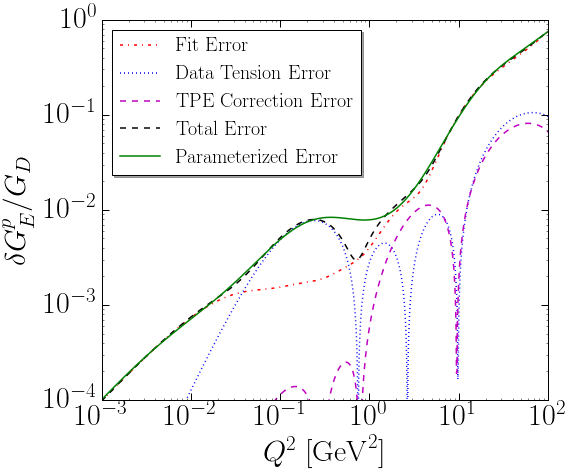

In [17]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2, GE_err_fit, 'k-.', color='r',  label='Fit Error', linewidth=1.5)
axes.plot(Q2, GE_err_model, 'k:', color='b',  label='Data Tension Error', linewidth=1.5)
axes.plot(Q2, GE_err_tpe, 'k--', color='m',  label='TPE Correction Error', linewidth=1.5)
axes.plot(Q2, GE_err_sum, 'k--', color='black',  label='Total Error', linewidth=1.5)
axes.plot(Q2, GE_err_rh, 'k-', color='g',  label='Parameterized Error', linewidth=1.5)

axes.set_xlim(1e-3, 1e2)
axes.set_ylim(1e-4, 1)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_E^p/G_{D}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='medium', numpoints=1)
axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('GEp_Error_Curves.pdf',bbox_inches='tight')
plt.savefig('GEp_Error_Curves.eps',bbox_inches='tight')
plt.savefig('GEp_Error_Curves.png',bbox_inches='tight')

#plt.savefig('GEp_Error_Curves_seg7.pdf',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves_seg7.eps',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves_seg7.png',bbox_inches='tight')

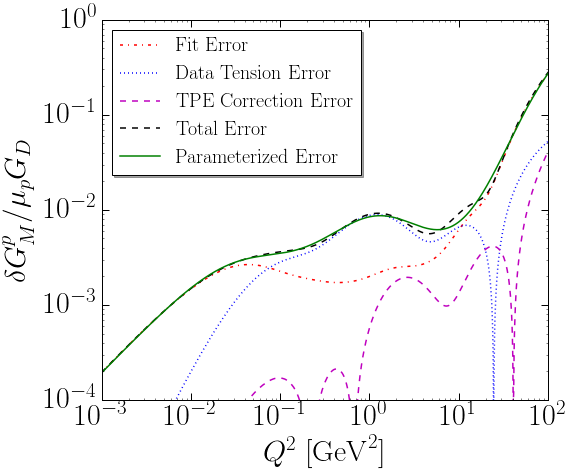

In [18]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GM/GD
axes.plot(Q2, GM_err_fit, 'k-.', color='r',  label='Fit Error', linewidth=1.5)
axes.plot(Q2, GM_err_model, 'k:', color='b',  label='Data Tension Error', linewidth=1.5)
axes.plot(Q2, GM_err_tpe, 'k--', color='m',  label='TPE Correction Error', linewidth=1.5)
axes.plot(Q2, GM_err_sum, 'k--', color='black',  label='Total Error', linewidth=1.5)
axes.plot(Q2, GM_err_rh, 'k-', color='g',  label='Parameterized Error', linewidth=1.5)

axes.set_xlim(1e-3, 1e2)
axes.set_ylim(1e-4, 1)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_M^p/\mu_p G_{D}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='medium', numpoints=1)
axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('GMp_Error_Curves.pdf',bbox_inches='tight')
plt.savefig('GMp_Error_Curves.eps',bbox_inches='tight')
plt.savefig('GMp_Error_Curves.png',bbox_inches='tight')

#plt.savefig('GMp_Error_Curves_seg7.pdf',bbox_inches='tight')
#plt.savefig('GMp_Error_Curves_seg7.eps',bbox_inches='tight')
#plt.savefig('GMp_Error_Curves_seg7.png',bbox_inches='tight')